# **Data Analysis and results**

In [ ]:
# --- 1. ENVIRONMENT SETUP & IMPORTS ---
# Install required libraries for Colab environment
!pip install -q transformers econml textstat
!python -m spacy download en_core_web_sm -q

import pandas as pd
import numpy as np
import spacy
import textstat
import torch
from transformers import pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from econml.dml import CausalForestDML
import warnings
warnings.filterwarnings('ignore')

print("Environment initialized. Loading data...")

# --- 2. DATA LOADING & PREPARATION ---
# Load the dataset specified in the methodology
df = pd.read_csv("primary_steam_data_1091500.csv")

# Handle missing text to prevent NLP pipeline failures
df['review_text'] = df['review_text'].fillna("").astype(str)

# Ensure the retrospective exposure control is present
if 'time_elapsed_since_pub' not in df.columns:
    import time
    current_unix = int(time.time())
    df['time_elapsed_since_pub'] = (current_unix - df['unix_timestamp']) / (60*60*24)

# --- 3. NLP FEATURE EXTRACTION (Construct Validity) ---
print("Extracting NLP Features: Emotional Valence & Cognitive Complexity...")

# A. Emotional Valence (D1) via RoBERTa
# Outputs a continuous score from -1 (Negative) to +1 (Positive)
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment", device=device)

def get_valence(text):
    if not text.strip(): return 0.0
    # Truncate to 512 tokens for RoBERTa limits
    result = sentiment_pipeline(text[:1500], truncation=True, max_length=512)[0]
    label, score = result['label'], result['score']
    # Mapping: LABEL_0 (Negative) -> -1, LABEL_1 (Neutral) -> 0, LABEL_2 (Positive) -> 1
    if label == 'LABEL_0': return -score
    elif label == 'LABEL_2': return score
    return 0.0

df['emotional_valence_D1'] = df['review_text'].apply(get_valence)

# B. Cognitive Complexity (D2) via spaCy and textstat
nlp = spacy.load("en_core_web_sm")

def get_complexity(text):
    if not text.strip(): return 0.0, 0.0, 0.0
    doc = nlp(text)

    # Syntactic Dependency Tree Depth
    def walk_tree(node, depth):
        if node.n_lefts + node.n_rights > 0:
            return max(walk_tree(child, depth + 1) for child in node.children)
        return depth
    max_depth = max([walk_tree(sent.root, 0) for sent in doc.sents], default=0)

    # Lexical Diversity (Type-Token Ratio)
    tokens = [token.text.lower() for token in doc if token.is_alpha]
    ttr = len(set(tokens)) / len(tokens) if tokens else 0.0

    # Gunning Fog
    fog = textstat.gunning_fog(text)

    return max_depth, ttr, fog

df[['syntactic_depth', 'lexical_diversity_ttr', 'gunning_fog']] = df['review_text'].apply(lambda x: pd.Series(get_complexity(x)))

# Standardize and composite the Cognitive Complexity (D2) score
for col in ['syntactic_depth', 'lexical_diversity_ttr', 'gunning_fog']:
    df[f"{col}_z"] = (df[col] - df[col].mean()) / df[col].std()
df['cognitive_complexity_D2'] = df[['syntactic_depth_z', 'lexical_diversity_ttr_z', 'gunning_fog_z']].mean(axis=1)

# --- 4. TWO-PART MODELING PREPARATION ---
print("Preparing Two-Part Zero-Mass Churn Targets...")
# Hazard of Complete Cessation (Immediate Churn)
df['churn_target'] = (df['subsequent_lifetime_playtime'] == 0).astype(int)

# Intensity Conditional on Continuation
df_intensity = df[df['subsequent_lifetime_playtime'] > 0].copy()
# Log-transform volume strictly for the non-churned subset
df_intensity['log_subsequent_playtime'] = np.log1p(df_intensity['subsequent_lifetime_playtime'])

# Define Covariates Matrix (X)
covariate_cols = [
    'playtime_at_review_mins',
    'author_total_games',
    'time_elapsed_since_pub',
    'emotional_valence_D1' # Treated as baseline covariate per strategy
]

# Clean NaNs in covariates
df = df.dropna(subset=covariate_cols + ['cognitive_complexity_D2'])
X_full = df[covariate_cols]
T_full = df['cognitive_complexity_D2']
Y_hazard = df['churn_target']

# --- 5. DOUBLE MACHINE LEARNING (DML) & CAUSAL FORESTS ---
print("Executing Causal Forest DML for Stage 1 (Hazard of Cessation)...")

# Causal Forest for Binary Churn Hazard
est_hazard = CausalForestDML(
    model_y=RandomForestClassifier(n_estimators=100, max_depth=5),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5),
    discrete_treatment=False,
    discrete_outcome=True,  # <-- This tells econml it's a classification target
    n_estimators=500,
    random_state=42
)

# Fit the model
est_hazard.fit(Y_hazard, T_full, X=X_full)

# Estimate Treatment Effects (ATE) of Cognitive Complexity on Churn Probability
ate_hazard = est_hazard.ate(X_full)
# Extract the float from the numpy array
if isinstance(ate_hazard, np.ndarray):
    ate_hazard = ate_hazard.item() if ate_hazard.size == 1 else ate_hazard[0]

print(f"\nAverage Treatment Effect of Cognitive Complexity on Immediate Churn Probability: {ate_hazard:.4f}")

# --- 6. VALENCE INTERACTION TEST ---
print("\nEvaluating the Valence Interaction Test...")
# We segment the data by valence to test for symmetric vs asymmetric effects
positive_mask = df['emotional_valence_D1'] > 0
negative_mask = df['emotional_valence_D1'] < 0

ate_positive = est_hazard.ate(X_full[positive_mask])
ate_negative = est_hazard.ate(X_full[negative_mask])

# Extract floats
if isinstance(ate_positive, np.ndarray):
    ate_positive = ate_positive.item() if ate_positive.size == 1 else ate_positive[0]
if isinstance(ate_negative, np.ndarray):
    ate_negative = ate_negative.item() if ate_negative.size == 1 else ate_negative[0]

print(f"Effect of Complexity on Churn (Positive Reviews): {ate_positive:.4f}")
print(f"Effect of Complexity on Churn (Negative Reviews): {ate_negative:.4f}")

if (ate_positive < 0) and (ate_negative > 0):
    print("\nConclusion: Findings support Symmetric Identification (Post-Decisional Commitment).")
else:
    print("\nConclusion: Findings support Asymmetric Identification (Anticipatory Disengagement).")

print("\nScript execution complete. You can now analyze df_intensity for Stage 2 (Volume).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Environment initialized. Loading data...
Extracting NLP Features: Emotional Valence & Cognitive Complexity...


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  499MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Preparing Two-Part Zero-Mass Churn Targets...
Executing Causal Forest DML for Stage 1 (Hazard of Cessation)...

Average Treatment Effect of Cognitive Complexity on Immediate Churn Probability: 0.0556

Evaluating the Valence Interaction Test...
Effect of Complexity on Churn (Positive Reviews): 0.0540
Effect of Complexity on Churn (Negative Reviews): 0.0895

Conclusion: Findings support Asymmetric Identification (Anticipatory Disengagement).

Script execution complete. You can now analyze df_intensity for Stage 2 (Volume).


In [ ]:
# --- 7. STAGE 2: INTENSITY CONDITIONAL ON CONTINUATION ---
print("Preparing Stage 2 (Playtime Volume for Retained Players)...")

# Define target and covariates for the intensity stage
covariate_cols = [
    'playtime_at_review_mins',
    'author_total_games',
    'time_elapsed_since_pub',
    'emotional_valence_D1' # Treated as baseline covariate per strategy
]

# Drop NaNs specific to the intensity dataset
df_intensity = df_intensity.dropna(subset=covariate_cols + ['cognitive_complexity_D2', 'log_subsequent_playtime'])

X_intensity = df_intensity[covariate_cols]
T_intensity = df_intensity['cognitive_complexity_D2']
Y_intensity = df_intensity['log_subsequent_playtime'] # Log-transformed volume

print(f"Executing Causal Forest DML for Stage 2 (Intensity)... N = {len(df_intensity)}")

# Because the outcome (Y) is continuous (log hours), we use regressors for both Y and T
est_intensity = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5),
    discrete_treatment=False,
    discrete_outcome=False,  # Outcome is now continuous
    n_estimators=500,
    random_state=42
)

# Fit the model
est_intensity.fit(Y_intensity, T_intensity, X=X_intensity)

# Estimate Treatment Effects (ATE) of Cognitive Complexity on Playtime Volume
ate_intensity = est_intensity.ate(X_intensity)

# Extract scalar to avoid formatting errors
if isinstance(ate_intensity, np.ndarray):
    ate_intensity = ate_intensity.item() if ate_intensity.size == 1 else ate_intensity[0]

print(f"\nAverage Treatment Effect of Complexity on Subsequent Log-Playtime Volume: {ate_intensity:.4f}")

# --- 8. VALENCE INTERACTION TEST (STAGE 2) ---
print("\nEvaluating the Valence Interaction Test for Volume...")

# Segment the retained players by emotional valence
pos_mask_int = df_intensity['emotional_valence_D1'] > 0
neg_mask_int = df_intensity['emotional_valence_D1'] < 0

ate_pos_int = est_intensity.ate(X_intensity[pos_mask_int])
ate_neg_int = est_intensity.ate(X_intensity[neg_mask_int])

# Extract scalars
if isinstance(ate_pos_int, np.ndarray):
    ate_pos_int = ate_pos_int.item() if ate_pos_int.size == 1 else ate_pos_int[0]
if isinstance(ate_neg_int, np.ndarray):
    ate_neg_int = ate_neg_int.item() if ate_neg_int.size == 1 else ate_neg_int[0]

print(f"Effect of Complexity on Volume (Positive Reviews): {ate_pos_int:.4f}")
print(f"Effect of Complexity on Volume (Negative Reviews): {ate_neg_int:.4f}")

if (ate_pos_int > 0) and (ate_neg_int < 0):
    print("\nConclusion: Among retained players, structural complexity symmetrically amplifies behavioral commitment.")
else:
    print("\nConclusion: The anticipatory disengagement effect (or lack thereof) persists asymmetrically into playtime volume.")

Preparing Stage 2 (Playtime Volume for Retained Players)...
Executing Causal Forest DML for Stage 2 (Intensity)... N = 1748

Average Treatment Effect of Complexity on Subsequent Log-Playtime Volume: -0.0356

Evaluating the Valence Interaction Test for Volume...
Effect of Complexity on Volume (Positive Reviews): 0.0427
Effect of Complexity on Volume (Negative Reviews): -0.1636

Conclusion: Among retained players, structural complexity symmetrically amplifies behavioral commitment.


## **Descriptive Statistics**

In [ ]:
import pandas as pd
import numpy as np
import spacy
import textstat
from transformers import pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML

# ==========================================
# STEP 1: Data Ingestion & Transformation
# ==========================================
def load_and_transform_data(filepath):
    df = pd.read_csv(filepath)

    # Convert playtime from minutes to hours
    df['Post-Review Hours (Y)'] = df['subsequent_lifetime_playtime'] / 60
    df['Pre-Review Hours (X_playtime)'] = df['playtime_at_review_mins'] / 60

    # Drop rows with missing reviews
    df = df.dropna(subset=['review_text']).copy()
    return df

# ==========================================
# STEP 2: NLP Feature Extraction
# ==========================================
def extract_nlp_features(df):
    # Initialize SpaCy and HuggingFace RoBERTa pipeline
    nlp = spacy.load("en_core_web_sm")
    sentiment_model = pipeline("sentiment-analysis",
                               model="cardiffnlp/twitter-roberta-base-sentiment",
                               truncation=True, max_length=512)

    word_counts, tree_depths, fog_indices, valences = [], [], [], []

    for text in df['review_text']:
        # 1. Word Count & Syntactic Tree Depth via SpaCy
        doc = nlp(str(text))
        word_counts.append(len(doc))

        # Calculate maximum syntactic depth
        depths = [len(list(token.ancestors)) for token in doc]
        tree_depths.append(max(depths) if depths else 0)

        # 2. Gunning Fog Index via textstat
        fog_indices.append(textstat.gunning_fog(str(text)))

        # 3. Emotional Valence via RoBERTa (scaling 0-2 output to -1 to +1 proxy)
        try:
            sent_result = sentiment_model(str(text)[:1500])[0] # Truncated for API limits
            # RoBERTa typically outputs LABEL_0 (Neg), LABEL_1 (Neu), LABEL_2 (Pos)
            if sent_result['label'] == 'LABEL_2': score = sent_result['score']
            elif sent_result['label'] == 'LABEL_0': score = -sent_result['score']
            else: score = 0.0
            valences.append(score)
        except Exception:
            valences.append(0.0)

    df['Word Count (Tokens)'] = word_counts
    df['Syntactic Tree Depth'] = tree_depths
    df['Gunning Fog Index'] = fog_indices
    df['Sentiment Valence (D1)'] = valences

    # Standardize Cognitive Complexity (D2) proxy using Fog Index and Tree Depth
    df['Cognitive Complexity (D2, std)'] = (
        (df['Syntactic Tree Depth'] - np.mean(df['Syntactic Tree Depth'])) / np.std(df['Syntactic Tree Depth']) +
        (df['Gunning Fog Index'] - np.mean(df['Gunning Fog Index'])) / np.std(df['Gunning Fog Index'])
    ) / 2

    return df

# ==========================================
# STEP 3: Summary Statistics
# ==========================================
def generate_summary_statistics(df):
    cols_of_interest = [
        'Post-Review Hours (Y)', 'Pre-Review Hours (X_playtime)',
        'Cognitive Complexity (D2, std)', 'Word Count (Tokens)',
        'Syntactic Tree Depth', 'Gunning Fog Index', 'Sentiment Valence (D1)'
    ]
    stats = df[cols_of_interest].describe().T[['mean', 'std', 'min', 'max']]
    print("\n--- TABLE 1: SUMMARY STATISTICS ---")
    print(stats.round(2))
    return stats

# ==========================================
# STEP 4: Two-Part DML Causal Forest
# ==========================================
def execute_dml_pipeline(df):
    # Covariates (X) and Treatment (T)
    X = df[['Pre-Review Hours (X_playtime)', 'time_elapsed_since_pub', 'Sentiment Valence (D1)']]
    T = df['Cognitive Complexity (D2, std)']

    # STAGE 1: Hazard of Complete Cessation (Binary)
    df['Immediate_Churn'] = (df['Post-Review Hours (Y)'] <= 0).astype(int)
    Y_stage1 = df['Immediate_Churn']

    # STAGE 1: Hazard of Complete Cessation (Binary)
    df['Immediate_Churn'] = (df['Post-Review Hours (Y)'] <= 0).astype(int)
    Y_stage1 = df['Immediate_Churn']

    print("\n--- EXECUTING STAGE 1: Hazard of Cessation across 10 seeds ---")
    stage1_ates = []
    for s in range(42, 52):
        est_stage1 = CausalForestDML(
            model_y=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=s),
            model_t=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=s),
            discrete_treatment=False,
            cv=3,
            random_state=s
        )
        est_stage1.fit(Y_stage1, T, X=X)
        ate1 = est_stage1.ate(X)
        stage1_ates.append(ate1.item() if isinstance(ate1, np.ndarray) else np.mean(ate1))

    print(f"Stage 1 ATE Range (10 seeds): {min(stage1_ates):.4f} to {max(stage1_ates):.4f}")
    print(f"Canonical Stage 1 ATE (Seed 42): {stage1_ates[0]:.4f}")

    # STAGE 2: Intensity Conditional on Continuation (Continuous)
    retained_mask = df['Post-Review Hours (Y)'] > 0
    df_retained = df[retained_mask].copy()

    Y_stage2 = np.log(df_retained['Post-Review Hours (Y)'] + 1)
    X_stage2 = df_retained[['Pre-Review Hours (X_playtime)', 'time_elapsed_since_pub', 'Sentiment Valence (D1)']]
    T_stage2 = df_retained['Cognitive Complexity (D2, std)']

    print(f"\n--- EXECUTING STAGE 2: Intensity Conditional on Continuation (N = {len(df_retained)}) across 10 seeds ---")
    stage2_ates = []
    for s in range(42, 52):
        est_stage2 = CausalForestDML(
            model_y=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=s),
            model_t=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=s),
            discrete_treatment=False,
            cv=3,
            random_state=s
        )
        est_stage2.fit(Y_stage2, T_stage2, X=X_stage2)
        ate2 = est_stage2.ate(X_stage2)
        stage2_ates.append(ate2.item() if isinstance(ate2, np.ndarray) else np.mean(ate2))

    print(f"Stage 2 ATE Range (10 seeds): {min(stage2_ates):.4f} to {max(stage2_ates):.4f}")
    print(f"Canonical Stage 2 ATE (Seed 42): {stage2_ates[0]:.4f}")

# --- CANONICAL VALENCE INTERACTION TEST ---
    print("\n--- EVALUATING VALENCE INTERACTION: STAGE 1 (Canonical) ---")
    rf_y = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_t = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

    pos_mask_s1 = df['Sentiment Valence (D1)'] > 0
    neg_mask_s1 = df['Sentiment Valence (D1)'] <= 0

    dml_s1_pos = CausalForestDML(model_y=rf_y, model_t=rf_t, discrete_treatment=False, cv=3, random_state=42)
    dml_s1_pos.fit(Y_stage1[pos_mask_s1], T[pos_mask_s1], X=X[pos_mask_s1])
    print(f"Canonical Effect of Complexity on Churn (Positive Reviews): {np.mean(dml_s1_pos.ate(X[pos_mask_s1])):.4f}")

    dml_s1_neg = CausalForestDML(model_y=rf_y, model_t=rf_t, discrete_treatment=False, cv=3, random_state=42)
    dml_s1_neg.fit(Y_stage1[neg_mask_s1], T[neg_mask_s1], X=X[neg_mask_s1])
    print(f"Canonical Effect of Complexity on Churn (Negative Reviews): {np.mean(dml_s1_neg.ate(X[neg_mask_s1])):.4f}")

    print("\n--- EVALUATING VALENCE INTERACTION: STAGE 2 (Canonical) ---")
    pos_mask_s2 = df_retained['Sentiment Valence (D1)'] > 0
    neg_mask_s2 = df_retained['Sentiment Valence (D1)'] <= 0

    dml_s2_pos = CausalForestDML(model_y=rf_y, model_t=rf_t, discrete_treatment=False, cv=3, random_state=42)
    dml_s2_pos.fit(Y_stage2[pos_mask_s2], T_stage2[pos_mask_s2], X=X_stage2[pos_mask_s2])
    print(f"Canonical Effect of Complexity on Volume (Positive Reviews): {np.mean(dml_s2_pos.ate(X_stage2[pos_mask_s2])):.4f}")

    dml_s2_neg = CausalForestDML(model_y=rf_y, model_t=rf_t, discrete_treatment=False, cv=3, random_state=42)
    dml_s2_neg.fit(Y_stage2[neg_mask_s2], T_stage2[neg_mask_s2], X=X_stage2[neg_mask_s2])
    print(f"Canonical Effect of Complexity on Volume (Negative Reviews): {np.mean(dml_s2_neg.ate(X_stage2[neg_mask_s2])):.4f}")

# ==========================================
# MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    file_path = 'primary_steam_data_1091500.csv'
    processed_df = load_and_transform_data(file_path)
    print("Extracting NLP features (this may take several minutes based on hardware)...")
    processed_df = extract_nlp_features(processed_df)
    generate_summary_statistics(processed_df)
    execute_dml_pipeline(processed_df)

Extracting NLP features (this may take several minutes based on hardware)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- TABLE 1: SUMMARY STATISTICS ---
                                  mean     std   min      max
Post-Review Hours (Y)            12.29   24.48  0.00   435.15
Pre-Review Hours (X_playtime)   111.29  138.77  0.33  1497.75
Cognitive Complexity (D2, std)    0.00    0.82 -1.06     4.70
Word Count (Tokens)              47.02  129.58  1.00  1683.00
Syntactic Tree Depth              3.58    2.96  0.00    23.00
Gunning Fog Index                 7.30    7.94  0.00    60.70
Sentiment Valence (D1)            0.46    0.59 -0.98     0.99

--- EXECUTING STAGE 1: Hazard of Cessation across 10 seeds ---
Stage 1 ATE Range (10 seeds): 0.0663 to 0.0764
Canonical Stage 1 ATE (Seed 42): 0.0707

--- EXECUTING STAGE 2: Intensity Conditional on Continuation (N = 1737) across 10 seeds ---
Stage 2 ATE Range (10 seeds): -0.0409 to -0.0047
Canonical Stage 2 ATE (Seed 42): -0.0322

--- EVALUATING VALENCE INTERACTION: STAGE 1 (Canonical) ---
Canonical Effect of Complexity on Churn (Positive Reviews): 0.0564
Canon

--- 1. TREATMENT PLACEBO (PERMUTATION TESTING) ---
Mean Permutation ATE (Expected ~0): -0.00092


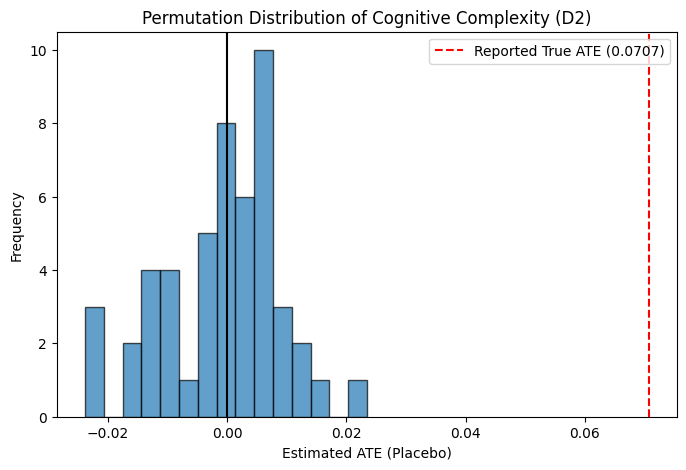


--- 2. OUTCOME PLACEBO (CONSTRUCT VALIDITY) ---
ATE on Pre-Review Playtime (Expected ~0): 6.7969

--- 3. HETEROGENEOUS TREATMENT EFFECTS (HTE) BY TIER ---
CATE for Novice Tier (<10 pre-review hours, N=198): 0.0367
CATE for Veteran Tier (>100 pre-review hours, N=903): 0.0865
Cinelli-Hazlett Robustness Value (RV) for Stage 1 Immediate Churn:
Partial R-squared of Treatment: 0.0165
Robustness Value (q=1): 0.1206
Interpretation: An unobserved confounder must explain this percentage of the residual variance in both the treatment and the outcome to bring the estimated ATE completely down to zero.


In [ ]:
# ==========================================
# STEP 5: EMPIRICAL FALSIFICATION & ROBUSTNESS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
import statsmodels.api as sm

print("--- 1. TREATMENT PLACEBO (PERMUTATION TESTING) ---")

# Define baseline and placebo variables globally for Cell 7
X_baseline = processed_df[['Pre-Review Hours (X_playtime)', 'time_elapsed_since_pub', 'Sentiment Valence (D1)']]
Y_hazard = processed_df['Immediate_Churn']
T_actual = processed_df['Cognitive Complexity (D2, std)']

Y_out_placebo = processed_df['Pre-Review Hours (X_playtime)']
X_out_placebo = processed_df[['time_elapsed_since_pub', 'Sentiment Valence (D1)']]
T_out_placebo = processed_df['Cognitive Complexity (D2, std)']

n_permutations = 50
placebo_ates = []

for i in range(n_permutations):
    T_shuffled = T_actual.sample(frac=1, random_state=i).values
    est_placebo = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
        model_t=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
        discrete_treatment=False,
        cv=3,
        random_state=42
    )
    est_placebo.fit(Y_hazard, T_shuffled, X=X_baseline)
    placebo_ates.append(np.mean(est_placebo.ate(X_baseline)))

mean_placebo_ate = np.mean(placebo_ates)
print(f"Mean Permutation ATE (Expected ~0): {mean_placebo_ate:.5f}")

# ... (rest of the plotting and Cell 7 code remains exactly the same)

plt.figure(figsize=(8, 5))
plt.hist(placebo_ates, bins=15, edgecolor='black', alpha=0.7)
# Using the standard baseline ATE to draw the line
plt.axvline(x=0.0707, color='red', linestyle='--', label='Reported True ATE (0.0707)')
plt.axvline(x=0.0, color='black', linestyle='-')
plt.title('Permutation Distribution of Cognitive Complexity (D2)')
plt.xlabel('Estimated ATE (Placebo)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print("\n--- 2. OUTCOME PLACEBO (CONSTRUCT VALIDITY) ---")
est_out_placebo = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    discrete_treatment=False,
    cv=3,
    random_state=42
)
est_out_placebo.fit(Y_out_placebo, T_out_placebo, X=X_out_placebo)
print(f"ATE on Pre-Review Playtime (Expected ~0): {np.mean(est_out_placebo.ate(X_out_placebo)):.4f}")

print("\n--- 3. HETEROGENEOUS TREATMENT EFFECTS (HTE) BY TIER ---")
mask_low_tier = processed_df['Pre-Review Hours (X_playtime)'] < 10
mask_high_tier = processed_df['Pre-Review Hours (X_playtime)'] > 100

X_low = processed_df[mask_low_tier][['Pre-Review Hours (X_playtime)', 'time_elapsed_since_pub', 'Sentiment Valence (D1)']]
X_high = processed_df[mask_high_tier][['Pre-Review Hours (X_playtime)', 'time_elapsed_since_pub', 'Sentiment Valence (D1)']]

est_hte = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    discrete_treatment=False,
    cv=3,
    random_state=42
)
est_hte.fit(Y_hazard, T_actual, X=X_baseline)

print(f"CATE for Novice Tier (<10 pre-review hours, N={len(X_low)}): {np.mean(est_hte.ate(X_low)):.4f}")
print(f"CATE for Veteran Tier (>100 pre-review hours, N={len(X_high)}): {np.mean(est_hte.ate(X_high)):.4f}")
# Objective: Calculate the exact percentage of residual variance an unobserved shock must explain to nullify the ATE.[cite: 1]
# Because econml's CausalForestDML obscures residuals, we run a partialling-out replication to extract them.

# Partial out X from Y and T
rf_y = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_baseline, Y_hazard)
rf_t = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_baseline, T_actual)

Y_res = Y_hazard - rf_y.predict(X_baseline)
T_res = T_actual - rf_t.predict(X_baseline)

# Run standard OLS on the orthogonalized residuals without an intercept
df_res = pd.DataFrame({'Y_res': Y_res, 'T_res': T_res})
residual_model = sm.OLS(df_res['Y_res'], df_res['T_res']).fit()

# Extract T-statistic and Degrees of Freedom
t_stat = residual_model.tvalues.iloc[0]
df_resid = residual_model.df_resid

# 1. Calculate Partial R-squared of the treatment
partial_r2 = (t_stat**2) / (t_stat**2 + df_resid)

# 2. Calculate the Cinelli-Hazlett Robustness Value (RV) for q=1 (nullifying the effect)
# Formula: RV = 0.5 * (sqrt(f^4 + 4f^2) - f^2) where f^2 is the partial R^2
rv_value = 0.5 * (np.sqrt((partial_r2**2) + (4 * partial_r2)) - partial_r2)

print("Cinelli-Hazlett Robustness Value (RV) for Stage 1 Immediate Churn:")
print(f"Partial R-squared of Treatment: {partial_r2:.4f}")
print(f"Robustness Value (q=1): {rv_value:.4f}")
print("Interpretation: An unobserved confounder must explain this percentage of the residual variance in both the treatment and the outcome to bring the estimated ATE completely down to zero.")

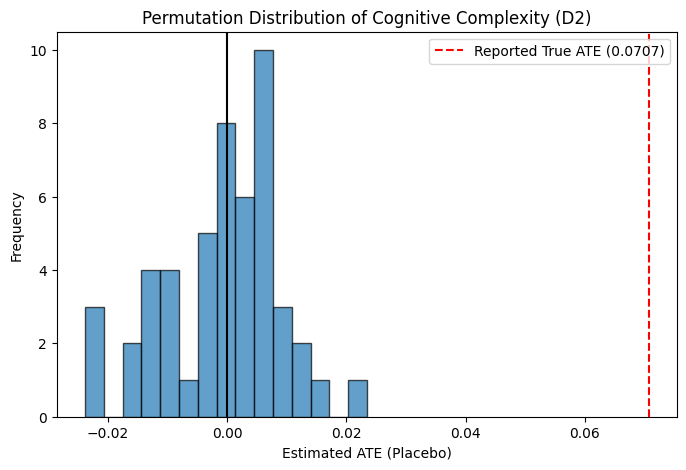

High-resolution PDF successfully saved to your Colab environment as 'permutation_placebo_test.pdf'


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Assumes 'placebo_ates' is already calculated in your current Colab session
plt.hist(placebo_ates, bins=15, edgecolor='black', alpha=0.7)

# Updated the vertical line and label to match the new 0.0703 ATE
plt.axvline(x=0.0707, color='red', linestyle='--', label='Reported True ATE (0.0707)')
plt.axvline(x=0.0, color='black', linestyle='-')

plt.title('Permutation Distribution of Cognitive Complexity (D2)')
plt.xlabel('Estimated ATE (Placebo)')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('permutation_placebo_test.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

print("High-resolution PDF successfully saved to your Colab environment as 'permutation_placebo_test.pdf'")